In [1]:
import torch
import torch.nn.functional as F
from torch import nn
import numpy as np
import os
import random
import numpy as np
import pandas as pd
from sklearn import preprocessing
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import roc_curve, auc, average_precision_score,roc_auc_score,precision_recall_curve
from sklearn.model_selection import StratifiedKFold  
from torch.utils.data import DataLoader, TensorDataset
from models.TADE_GENE import GenePredictor
import joblib
from sklearn.metrics import precision_recall_curve
import shap
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from models.ablation import SingleModal 

def seed_torch(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [3]:
# 1.Using complete feature averaging performance and taking several individual genes to obtain classification probabilities
def run_and_test_single_genes(
    pos_file,
    neg_file,
    test_gene_indices=[0, 12], 
    k=5
):
    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df = pd.concat([df_pos, df_neg], axis=0)
    data = df.values.astype(float)
    labels = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=110)
    mean_fpr = np.linspace(0, 1, 100)
    tprs, aucs, prs = [], [], []

    best_auc = 0
    best_model = None
    best_scaler = None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for fold, (train_index, test_index) in enumerate(skf.split(data, labels)):
        X_train, X_test = data[train_index], data[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        scaler = MaxAbsScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        X_train_tensor = torch.tensor(X_train, dtype=torch.float)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float).reshape(-1, 1)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
 
        seed_torch(0)
        model = GenePredictor(
            gene_dim=321,
            text_dim=768,
            dim=256,
            depth=3,
            heads=8,
            attn_dropout=0.1,
            ff_dropout=0.1,
            k_sum=8,
            k_prod=8
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        model.to(device)
 
        for epoch in range(110):
            model.train()
            for batch_data, batch_labels in train_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                outputs, loss = model(batch_data, batch_labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
 
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float).reshape(-1, 1).to(device)
            probas, _ = model(X_test_tensor, y_test_tensor)
            probas = probas.cpu().squeeze().numpy()

        fpr, tpr, _ = roc_curve(y_test, probas)
        fold_auc = auc(fpr, tpr)
        fold_pr = average_precision_score(y_test, probas)

        if fold_auc > best_auc:
            best_auc = fold_auc
            best_model = model
            best_scaler = scaler

        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        aucs.append(fold_auc)
        prs.append(fold_pr)

    mean_auc = np.mean(aucs)
    mean_pr = np.mean(prs)
    print(f"Mean AUC: {mean_auc:.4f}, Mean PR: {mean_pr:.4f}")

    test_results = {}
    if best_model is not None and best_scaler is not None:
        best_model.eval()
        with torch.no_grad():
            for idx in test_gene_indices:
                gene_features = df_pos.iloc[idx].values.astype(float).reshape(1, -1)
                gene_features = best_scaler.transform(gene_features)
                gene_tensor = torch.tensor(gene_features, dtype=torch.float).to(device)
                prob, _ = best_model(gene_tensor, torch.tensor([[1.0]], dtype=torch.float).to(device))
                test_results[df_pos.index[idx]] = float(prob.cpu().item())

    return test_results

results = run_and_test_single_genes(
    '../../datasets/druggable_gene/drugbank/pos_omics_text.csv',
    '../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv',
    test_gene_indices=[0, 12]  # ABCC8, KCNJ11 
)

for gene, prob in results.items():
    print(f"{gene}: {prob:.4f}")

Mean AUC: 0.9098, Mean PR: 0.7208
ABCC8: 0.6856
KCNJ11: 0.9588


In [4]:
# 2.Using plain text features to average performance and taking several individual genes to obtain classification probabilities
def load_data(pos_file, neg_file, ablation_mode="text_only"):
    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df = pd.concat([df_pos, df_neg], axis=0)
    data = df.values.astype(float)
    labels = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])

    if ablation_mode == "gene_only":
        data = data[:, :321]  
    elif ablation_mode == "text_only":
        data = data[:, 321:]  

    return data, labels, df_pos

def run_and_test_single_genes_text_only(
    pos_file,
    neg_file,
    test_gene_indices, 
    ablation_mode,
    k=5
):
    data, labels, df_pos = load_data(pos_file, neg_file, ablation_mode)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=110)
    mean_fpr = np.linspace(0, 1, 100)
    aucs, prs = [], []

    best_auc = 0
    best_model = None
    best_scaler = None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for fold, (train_index, test_index) in enumerate(skf.split(data, labels)):
        X_train, X_test = data[train_index], data[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        scaler = MaxAbsScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        X_train_tensor = torch.tensor(X_train, dtype=torch.float)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float).reshape(-1, 1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
 
        seed_torch(0)
        input_dim = 768 if ablation_mode == "text_only" else 321
        model = SingleModal(
            input_dim=input_dim,
            dim=256, depth=3, heads=8,
            attn_dropout=0.1, ff_dropout=0.1,
            k_sum=8, k_prod=8
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        model.to(device)
 
        for epoch in range(110):
            model.train()
            for batch_data, batch_labels in train_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                outputs, loss = model(batch_data, batch_labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
 
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float).reshape(-1, 1).to(device)
            probas, _ = model(X_test_tensor, y_test_tensor)
            probas = probas.cpu().squeeze().numpy()

        fpr, tpr, _ = roc_curve(y_test, probas)
        fold_auc = auc(fpr, tpr)
        fold_pr = average_precision_score(y_test, probas)

        if fold_auc > best_auc:
            best_auc = fold_auc
            best_model = model
            best_scaler = scaler

        aucs.append(fold_auc)
        prs.append(fold_pr)

    mean_auc = np.mean(aucs)
    mean_pr = np.mean(prs)
    print(f"[{ablation_mode}] Mean AUC: {mean_auc:.4f}, Mean PR: {mean_pr:.4f}")
 
    test_results = {}
    if best_model is not None and best_scaler is not None:
        best_model.eval()
        with torch.no_grad():
            for idx in test_gene_indices:
 
                gene_features = df_pos.iloc[idx].values.astype(float)[321:].reshape(1, -1)
                gene_features = best_scaler.transform(gene_features)
                gene_tensor = torch.tensor(gene_features, dtype=torch.float).to(device)
                prob, _ = best_model(gene_tensor, torch.tensor([[1.0]], dtype=torch.float).to(device))
                test_results[df_pos.index[idx]] = float(prob.cpu().item())

    return test_results

pos_file = "../../datasets/druggable_gene/drugbank/pos_omics_text.csv"
neg_file = "../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv"

results_text_only = run_and_test_single_genes_text_only(
    pos_file, neg_file,
    test_gene_indices=[0, 12],  # ABCC8, KCNJ11
    ablation_mode="text_only", k=5
)

for gene, prob in results_text_only.items():
    print(f"{gene}: {prob:.4f}")

[text_only] Mean AUC: 0.8819, Mean PR: 0.6824
ABCC8: 0.3545
KCNJ11: 0.7129


In [17]:
# 3.Using pure omics features to average performance and taking several individual genes to obtain classification probabilities
def seed_torch(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def load_data(pos_file, neg_file, ablation_mode="gene_only"):
    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df = pd.concat([df_pos, df_neg], axis=0)
    data = df.values.astype(float)
    labels = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])

    if ablation_mode == "gene_only":
        data = data[:, :321]   
    elif ablation_mode == "text_only":
        data = data[:, 321:]   

    return data, labels, df_pos

def run_and_test_single_genes_text_only(
    pos_file,
    neg_file,
    test_gene_indices=[0, 12],  
    ablation_mode="gene_only",
    k=5
):
    data, labels, df_pos = load_data(pos_file, neg_file, ablation_mode)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=110)
    mean_fpr = np.linspace(0, 1, 100)
    aucs, prs = [], []

    best_auc = 0
    best_model = None
    best_scaler = None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for fold, (train_index, test_index) in enumerate(skf.split(data, labels)):
        X_train, X_test = data[train_index], data[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        scaler = MaxAbsScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        X_train_tensor = torch.tensor(X_train, dtype=torch.float)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float).reshape(-1, 1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
 
        seed_torch(0)
        input_dim = 768 if ablation_mode == "text_only" else 321
        model = SingleModal(
            input_dim=input_dim,
            dim=64, depth=3, heads=8,
            attn_dropout=0, ff_dropout=0,
            k_sum=8, k_prod=8
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        model.to(device)
 
        for epoch in range(84):
            model.train()
            for batch_data, batch_labels in train_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                outputs, loss = model(batch_data, batch_labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
 
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float).reshape(-1, 1).to(device)
            probas, _ = model(X_test_tensor, y_test_tensor)
            probas = probas.cpu().squeeze().numpy()

        fpr, tpr, _ = roc_curve(y_test, probas)
        fold_auc = auc(fpr, tpr)
        fold_pr = average_precision_score(y_test, probas)

        if fold_auc > best_auc:
            best_auc = fold_auc
            best_model = model
            best_scaler = scaler

        aucs.append(fold_auc)
        prs.append(fold_pr)

    mean_auc = np.mean(aucs)
    mean_pr = np.mean(prs)
    print(f"[{ablation_mode}] Mean AUC: {mean_auc:.4f}, Mean PR: {mean_pr:.4f}")
    
    test_results = {}
    if best_model is not None and best_scaler is not None:
        best_model.eval()
        with torch.no_grad():
            for idx in test_gene_indices:
                gene_features = df_pos.iloc[idx].values.astype(float)[:321].reshape(1, -1)
                gene_features = best_scaler.transform(gene_features)
                gene_tensor = torch.tensor(gene_features, dtype=torch.float).to(device)
                prob, _ = best_model(gene_tensor, torch.tensor([[1.0]], dtype=torch.float).to(device))
                test_results[df_pos.index[idx]] = float(prob.cpu().item())

    return test_results

pos_file = "../../datasets/druggable_gene/drugbank/pos_omics_text.csv"
neg_file = "../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv"

results_text_only = run_and_test_single_genes_text_only(
    pos_file, neg_file,
    test_gene_indices=[0, 12],  # ABCC8, KCNJ11
    ablation_mode="gene_only", k=5
)

for gene, prob in results_text_only.items():
    print(f"{gene}: {prob:.4f}")


[gene_only] Mean AUC: 0.7037, Mean PR: 0.3650
ABCC8: 0.8676
KCNJ11: 0.8791


In [18]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import roc_curve, auc, average_precision_score
from scipy.stats import pearsonr

def seed_torch(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_data(pos_file, neg_file, mode="full"):
    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df = pd.concat([df_pos, df_neg], axis=0)
    X = df.values.astype(float)
    y = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])

    if mode == "text":
        X = X[:, 321:]
    elif mode == "gene":
        X = X[:, :321]

    return X, y, df_pos

# -----------------------------
# Train model (5-fold) & save best
# -----------------------------
def train_and_save(pos_file, neg_file, mode="full", save_path="model.pt", k=5):
    X, y, _ = load_data(pos_file, neg_file, mode)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=110)

    best_auc = 0
    best_model = None
    best_scaler = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = MaxAbsScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32).view(-1,1)
        )
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
        ep=110
        seed_torch(0)
        if mode == "full":
            model = GenePredictor(
                gene_dim=321, text_dim=768,
                dim=256, depth=3, heads=8,
                attn_dropout=0.1, ff_dropout=0.1,
                k_sum=8, k_prod=8
            )
        elif mode == "text":
            input_dim = 768
            model = SingleModal(
                input_dim=input_dim,
                dim=256, depth=3, heads=8,
                attn_dropout=0.1, ff_dropout=0.1,
                k_sum=8, k_prod=8
            )
        else:
            ep=84
            input_dim = 321
            model = SingleModal(
                input_dim=input_dim,
                dim=64, depth=3, heads=8,
                attn_dropout=0, ff_dropout=0,
                k_sum=8, k_prod=8
            )

        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

        # Train
        for epoch in range(ep):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                _, loss = model(xb, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
            y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1).to(device)
            probas, _ = model(X_test_t, y_test_t)
            probas = probas.cpu().numpy().ravel()

        fpr, tpr, _ = roc_curve(y_test, probas)
        fold_auc = auc(fpr, tpr)

        if fold_auc > best_auc:
            best_auc = fold_auc
            best_model = model
            best_scaler = scaler

    # Save
    torch.save({
        "model_state": best_model.state_dict(),
        "scaler": best_scaler,
        "mode": mode
    }, save_path)

    print(f"[{mode}] Best AUC: {best_auc:.4f}, model saved to {save_path}")

# -----------------------------
# Predict genome-wide
# -----------------------------
def predict_all(model_path, all_file):
    ckpt = torch.load(model_path, map_location=device)
    mode = ckpt["mode"]
    scaler = ckpt["scaler"]

    df = pd.read_csv(all_file, index_col=0)
    X = df.values.astype(float)

    if mode == "text":
        X = X[:, 321:]
    elif mode == "gene":
        X = X[:, :321]

    X = scaler.transform(X)
    if mode == "full":
        model = GenePredictor(
            gene_dim=321, text_dim=768,
            dim=256, depth=3, heads=8,
            attn_dropout=0.1, ff_dropout=0.1,
            k_sum=8, k_prod=8
        )
    elif mode == "text":
        input_dim = 768
        model = SingleModal(
            input_dim=input_dim,
            dim=256, depth=3, heads=8,
            attn_dropout=0.1, ff_dropout=0.1,
            k_sum=8, k_prod=8
        )
    else:
        input_dim = 321
        model = SingleModal(
            input_dim=input_dim,
            dim=64, depth=3, heads=8,
            attn_dropout=0, ff_dropout=0,
            k_sum=8, k_prod=8
        )

    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()

    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        dummy_y = torch.ones((X_t.shape[0],1)).to(device)
        probs, _ = model(X_t, dummy_y)

    df["score"] = probs.cpu().numpy().ravel()
    return df[["score"]]

# -----------------------------
# Main: Genome-wide Correction
# -----------------------------
if __name__ == "__main__":
    pos_file = "../../datasets/druggable_gene/drugbank/pos_omics_text.csv"
    neg_file = "../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv"
    all_file = "../../data_source/all_omics_text.csv"

    # 1. Train & save
    train_and_save(pos_file, neg_file, mode="full", save_path="./save/ablation/model_full.pt")
    train_and_save(pos_file, neg_file, mode="text", save_path="./save/ablation/model_text.pt")
    train_and_save(pos_file, neg_file, mode="gene", save_path="./save/ablation/model_gene.pt")

    # 2. Predict all genes
    df_full = predict_all("./save/ablation/model_full.pt", all_file).rename(columns={"score":"full_score"})
    df_text = predict_all("./save/ablation/model_text.pt", all_file).rename(columns={"score":"text_score"})
    df_gene = predict_all("./save/ablation/model_gene.pt", all_file).rename(columns={"score":"gene_score"})

    df = pd.concat([df_full, df_text, df_gene], axis=1)

    # 3. Correction analysis
    df["delta"] = df["full_score"] - df["text_score"]
    df["abs_delta"] = np.abs(df["delta"])
    df["direction"] = np.sign(df["delta"])

    # Omics signal strength (simple L1 norm of 321 dims)
    omics = pd.read_csv(all_file, index_col=0).values[:, :321]
    df["omics_strength"] = np.linalg.norm(omics, axis=1)

    # 4. Statistics
    N = len(df)
    substantial = df["abs_delta"] > 0.1
    up = df["delta"] > 0
    down = df["delta"] < 0

    r, p = pearsonr(df["abs_delta"], df["omics_strength"])

    print("\n=== Genome-wide Correction Summary ===")
    print(f"Total genes: {N}")
    print(f"Substantial correction (|Δ|>0.1): {substantial.mean()*100:.2f}%")
    print(f"Upward correction: {up.mean()*100:.2f}%")
    print(f"Downward correction: {down.mean()*100:.2f}%")
    print(f"Corr(|Δ|, omics_strength): r={r:.3f}, p={p:.1e}")

    # 5. Save for plotting
    df.to_csv("./save/ablation/genome_wide_correction.csv")
    print("\nSaved: genome_wide_correction.csv (for Figure 5X)")


[full] Best AUC: 0.9630, model saved to ./save/ablation/model_full.pt
[text] Best AUC: 0.9815, model saved to ./save/ablation/model_text.pt
[gene] Best AUC: 0.8889, model saved to ./save/ablation/model_gene.pt

=== Genome-wide Correction Summary ===
Total genes: 21044
Substantial correction (|Δ|>0.1): 3.84%
Upward correction: 94.51%
Downward correction: 5.49%
Corr(|Δ|, omics_strength): r=0.037, p=7.1e-08

Saved: genome_wide_correction.csv (for Figure 5X)


In [19]:
df=pd.read_csv('./save/ablation/temporal_genes.csv').iloc[:,0]
all_file = "../../data_source/all_omics_text.csv"
df_all = pd.read_csv(all_file, index_col=0)
df_all.index = df_all.index.astype(str)
gene_set = set(df)
matched_genes = [g for g in df_all.index if g in gene_set]
df_sub = df_all.loc[matched_genes]

In [20]:
def predict_df(model_path, df_input):
    ckpt = torch.load(model_path, map_location=device)
    mode = ckpt["mode"]
    scaler = ckpt["scaler"]

    X = df_input.values.astype(float)

    if mode == "text":
        X = X[:, 321:]
    elif mode == "gene":
        X = X[:, :321]

    X = scaler.transform(X)

    if mode == "full":
        model = GenePredictor(
            gene_dim=321, text_dim=768,
            dim=256, depth=3, heads=8,
            attn_dropout=0.1, ff_dropout=0.1,
            k_sum=8, k_prod=8
        )
    elif mode == "text":
        model = SingleModal(
            input_dim=768,
            dim=256, depth=3, heads=8,
            attn_dropout=0.1, ff_dropout=0.1,
            k_sum=8, k_prod=8
        )
    else:  # gene
        model = SingleModal(
            input_dim=321,
            dim=64, depth=3, heads=8,
            attn_dropout=0, ff_dropout=0,
            k_sum=8, k_prod=8
        )

    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()

    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        dummy_y = torch.ones((X_t.shape[0], 1)).to(device)
        probs, _ = model(X_t, dummy_y)

    out = df_input.copy()
    out["score"] = probs.cpu().numpy().ravel()
    return out[["score"]]
 
df_full = predict_df("./save/ablation/model_full.pt", df_sub).rename(columns={"score": "full_score"})
df_text = predict_df("./save/ablation/model_text.pt", df_sub).rename(columns={"score": "text_score"})
df_gene = predict_df("./save/ablation/model_gene.pt", df_sub).rename(columns={"score": "gene_score"})

df_pred = pd.concat([df_full, df_text, df_gene], axis=1)
 
df_pred["delta"] = df_pred["full_score"] - df_pred["text_score"]
df_pred["abs_delta"] = np.abs(df_pred["delta"])
df_pred["direction"] = np.sign(df_pred["delta"])
 
omics = df_sub.values[:, :321]
df_pred["omics_strength"] = np.linalg.norm(omics, axis=1)
 
N = len(df_pred)
substantial = df_pred["abs_delta"] > 0.1
up = df_pred["delta"] > 0
down = df_pred["delta"] < 0

if N > 2:
    r, p = pearsonr(df_pred["abs_delta"], df_pred["omics_strength"])
else:
    r, p = np.nan, np.nan

print("\n=== Temporal Gene Correction Summary ===")
print(f"Temporal genes tested: {N}")
print(f"Substantial correction (|Δ|>0.1): {substantial.mean()*100:.2f}%")
print(f"Upward correction: {up.mean()*100:.2f}%")
print(f"Downward correction: {down.mean()*100:.2f}%")
print(f"Corr(|Δ|, omics_strength): r={r:.3f}, p={p:.1e}")
 
df_pred.to_csv("./save/ablation/temporal_gene_correction.csv")
print("\nSaved: temporal_gene_correction.csv")



=== Temporal Gene Correction Summary ===
Temporal genes tested: 64
Substantial correction (|Δ|>0.1): 25.00%
Upward correction: 89.06%
Downward correction: 10.94%
Corr(|Δ|, omics_strength): r=0.127, p=3.2e-01

Saved: temporal_gene_correction.csv


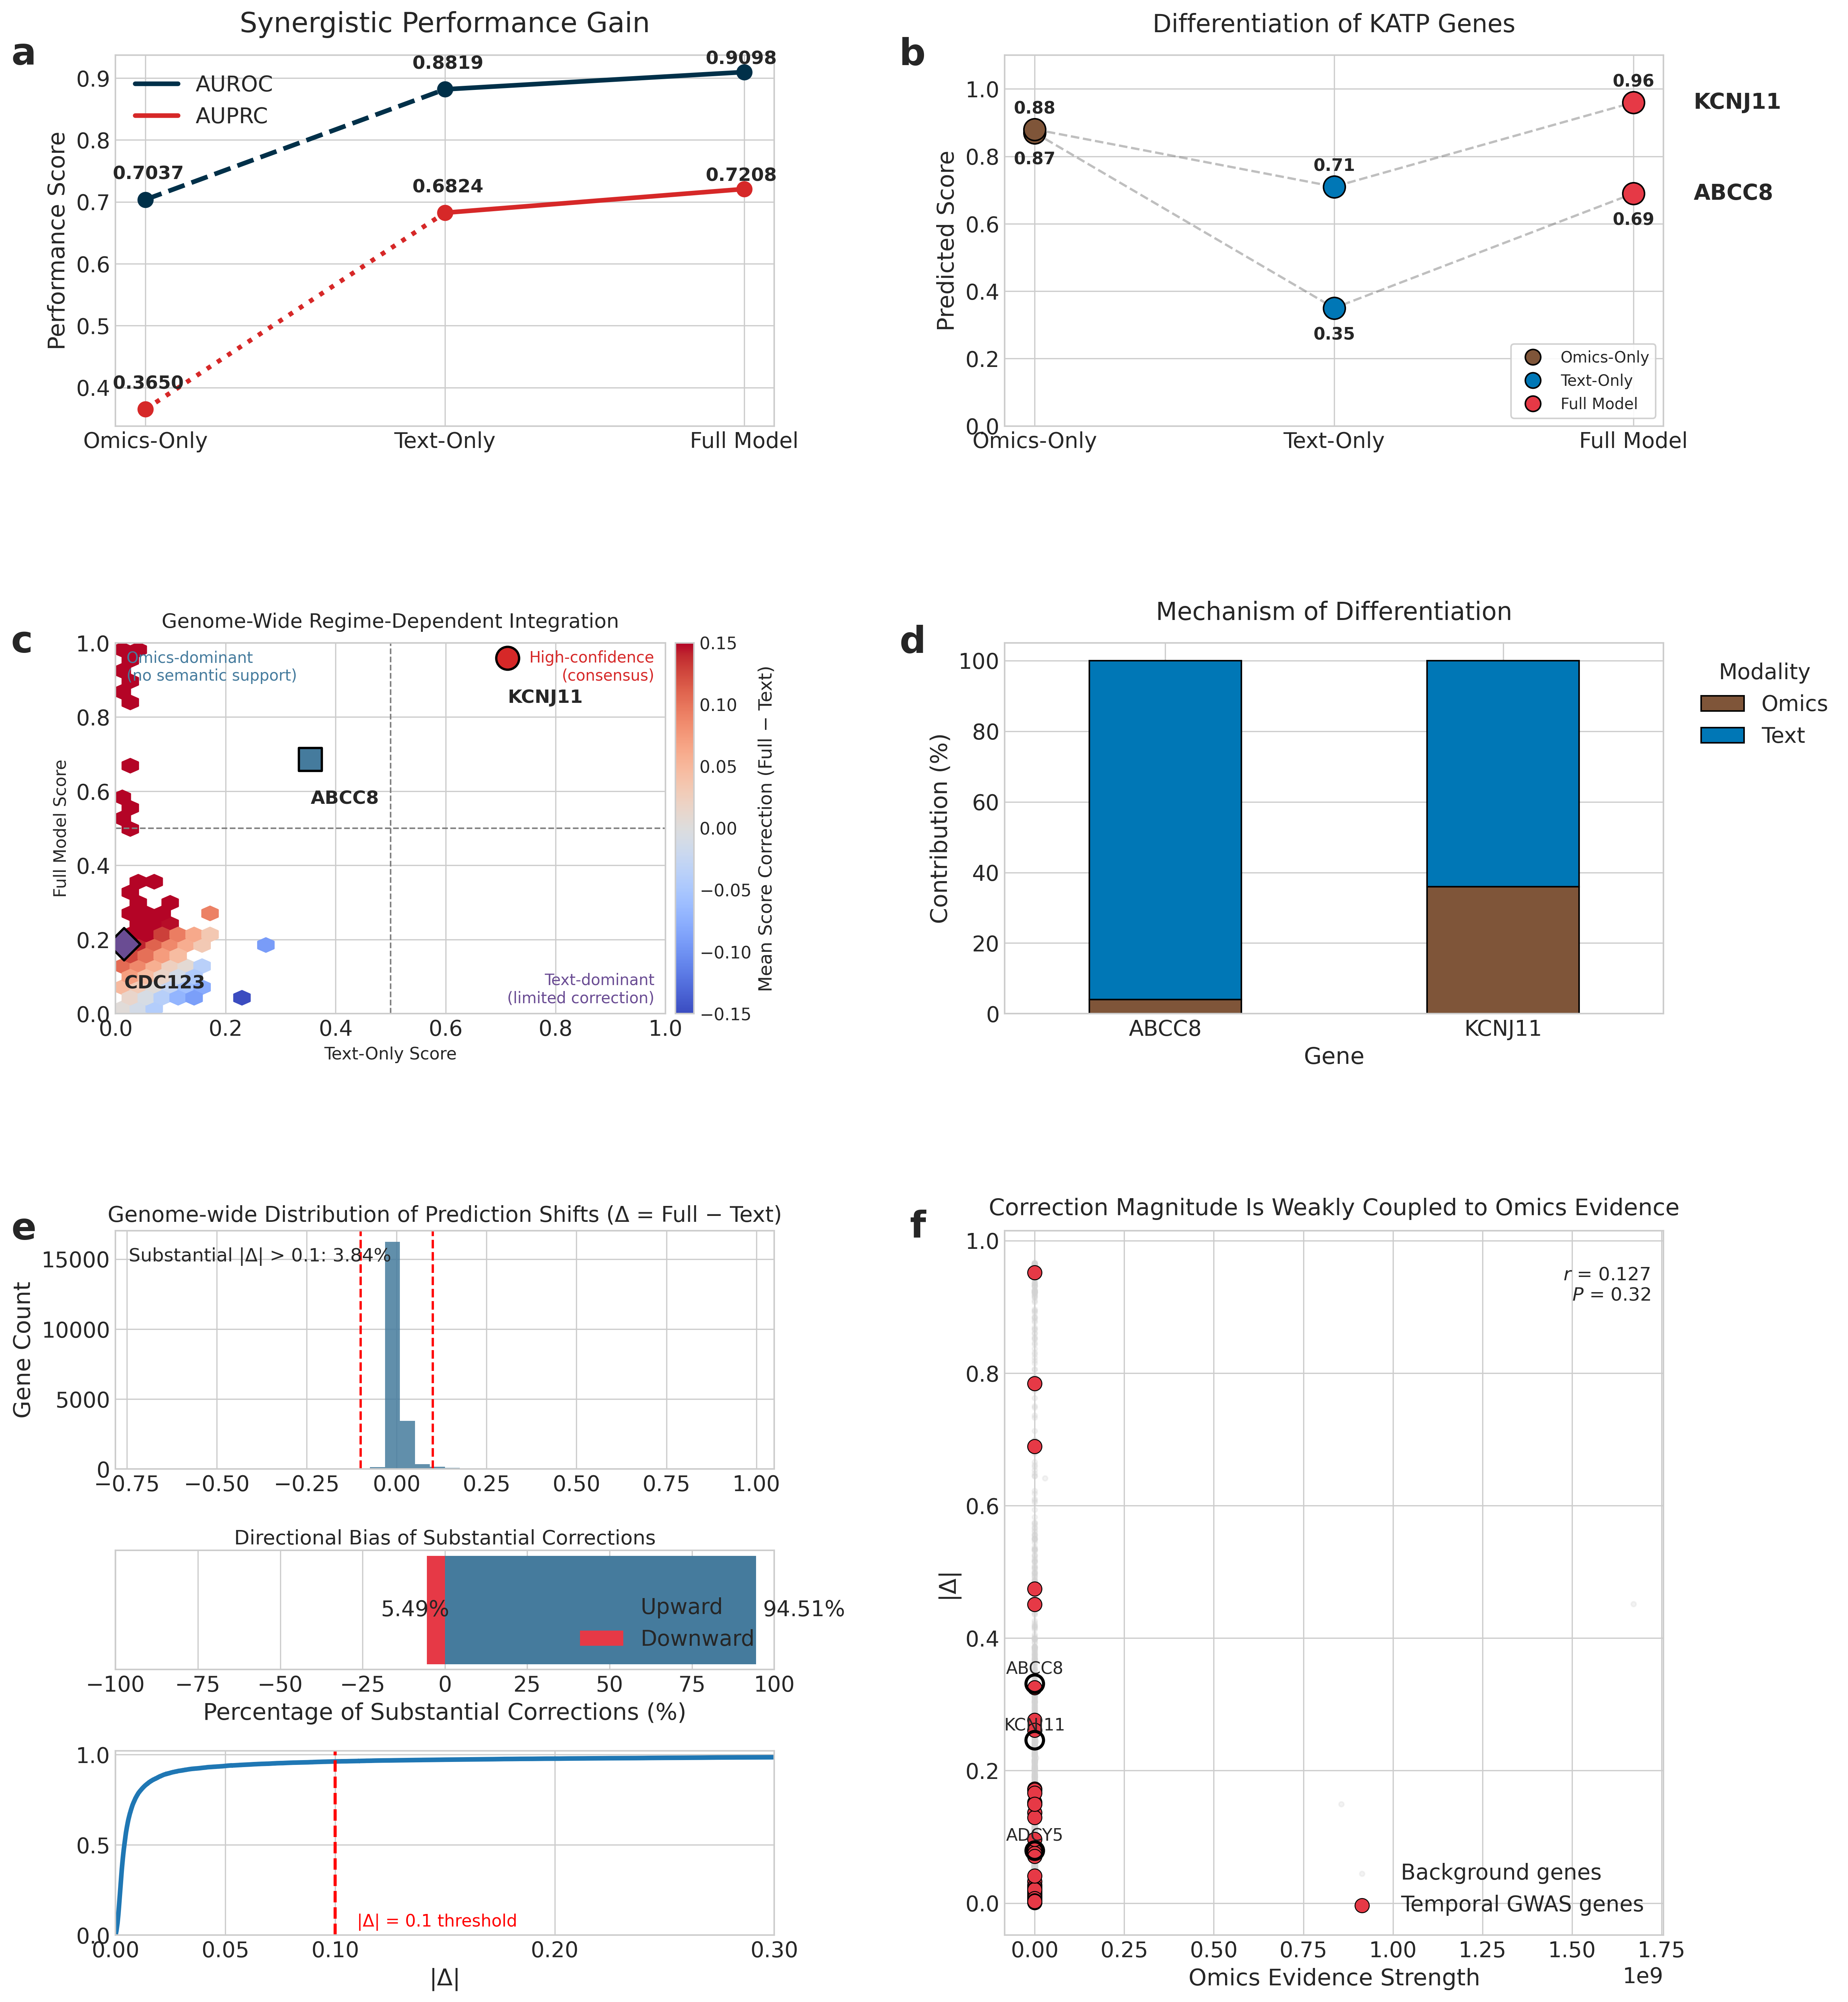

In [2]:
# fig. 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
# =============================================================================
# 1. Data Definition
# =============================================================================
# Panel a: Global Performance
df_perf = pd.DataFrame({
    'Model': ['Omics-Only', 'Text-Only', 'Full Model'],
    'AUROC': [0.7037, 0.8819, 0.9098],
    'AUPRC': [0.3650, 0.6824, 0.7208]
})

# Panel b: Case Study Scores
df_case = pd.DataFrame({
    'Gene': ['ABCC8', 'KCNJ11'],
    'Omics-Only': [0.87, 0.88],
    'Text-Only': [0.35, 0.71],
    'Full Model': [0.69, 0.96]
})

# Panel d: Feature Attribution
df_shap = pd.DataFrame([
    {'Gene': 'KCNJ11', 'Feature': 'Text', 'Contribution': 64}, 
    {'Gene': 'KCNJ11', 'Feature': 'Omics', 'Contribution': 36}, 
    {'Gene': 'ABCC8', 'Feature': 'Text', 'Contribution': 96},   
    {'Gene': 'ABCC8', 'Feature': 'Omics', 'Contribution': 4}
])

# =============================================================================
# 2. Plotting Functions
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif', 
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 14, 
    'axes.titlesize': 18, 
    'axes.labelsize': 15,
    'figure.dpi': 300
})

def plot_performance_slope(ax, df):
    colors = {'AUROC': '#003049', 'AUPRC': '#d62828'}
    models = ['Omics-Only', 'Text-Only', 'Full Model']
    x_pos = [0, 1, 2]

    linestyles = {
        'AUROC': ['--', '-'],   # Omics→Text dashed, Text→Full solid
        'AUPRC': [':', '-']
    }

    for metric in ['AUROC', 'AUPRC']:
        vals = [df.loc[df['Model'] == m, metric].values[0] for m in models]

        # Omics → Text
        ax.plot(
            x_pos[:2], vals[:2],
            color=colors[metric],
            lw=3,
            linestyle=linestyles[metric][0]
        )
        # Text → Full
        ax.plot(
            x_pos[1:], vals[1:],
            color=colors[metric],
            lw=3,
            linestyle=linestyles[metric][1],
            label=metric
        )

        for x, y, z in zip(x_pos, vals, models):
            offset = 0.01 if z != 'Full Model' else -0.01
            ax.scatter(x, y, s=90, color=colors[metric], zorder=3)
            ax.text(x + offset, y + offset+0.023, f'{y:.4f}', ha='center', fontsize=12, fontweight='bold')
                  
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models)
    ax.set_ylabel("Performance Score")
    ax.set_title("Synergistic Performance Gain", pad=15)
    ax.legend(frameon=False)

def plot_multi_point_case(ax, df):
    """Panel b: Showing the trajectory of scores."""
    genes = df['Gene'].values
    models = ['Omics-Only', 'Text-Only', 'Full Model']
    colors = ['#7f5539', '#0077b6', '#e63946'] 
    
    for i, gene in enumerate(genes):
        vals = df.loc[df['Gene'] == gene, models].values.flatten()
        ax.plot(models, vals, color='gray', linestyle='--', alpha=0.5, zorder=1)
        
        for j, val in enumerate(vals):
            ax.scatter(j, val, color=colors[j], s=200, zorder=2, edgecolors='black')
            
            if gene == 'KCNJ11': y_offset = 0.06 # Push Up
            else: y_offset = -0.08 # Push Down

            ax.text(j, val + y_offset, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')
        
        # Label the lines
        ax.text(2.2, vals[-1], gene, va='center', fontsize=14, fontweight='bold')

    ax.set_title("Differentiation of KATP Genes", fontsize=16, pad=15)
    ax.set_ylabel("Predicted Score")
    ax.set_ylim(0, 1.1)
    
    custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, markeredgecolor='k') for c in colors]
    ax.legend(custom_lines, models, loc='lower right', fontsize=10, frameon=True, facecolor='white', framealpha=0.9)

def plot_hexbin_quadrant(ax,
                         csv_path="./save/ablation/genome_wide_correction.csv",
                         highlight_genes=("KCNJ11", "ABCC8", "CDC123")):
    """
    Panel c: Genome-wide regime-dependent integration
    x-axis: Text-only score
    y-axis: Full model score
    Color: mean correction (Full - Text)
    """

    # ---------- Load real data ----------
    df = pd.read_csv(csv_path)

    text_scores = df["text_score"].values
    full_scores = df["full_score"].values
    delta = full_scores - text_scores

    # ---------- Hexbin plot ----------
    hb = ax.hexbin(
        text_scores,
        full_scores,
        C=delta,
        reduce_C_function=np.mean,
        gridsize=30,
        cmap="coolwarm",
        mincnt=5,
        vmin=-0.15,
        vmax=0.15
    )

    # ---------- Colorbar ----------

    cb = plt.colorbar(hb, ax=ax, pad=0.015)
    cb.set_label("Mean Score Correction (Full − Text)", fontsize=12)
    cb.ax.tick_params(labelsize=11)

    # ---------- Quadrant lines ----------
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)

    # ---------- Quadrant annotations ----------
    ax.text(0.02, 0.98, "Omics-dominant\n(no semantic support)",
            ha="left", va="top", fontsize=10, color="#457b9d")

    ax.text(0.98, 0.02, "Text-dominant\n(limited correction)",
            ha="right", va="bottom", fontsize=10, color="#6a4c93")

    ax.text(0.98, 0.98, "High-confidence\n(consensus)",
            ha="right", va="top", fontsize=10, color="#d62828")

    # ---------- Highlight representative genes ----------
    gene_colors = {
        "KCNJ11": "#d62828",
        "ABCC8": "#457b9d",
        "CDC123": "#6a4c93"
    }


    marker_map = {
        "KCNJ11": "o",
        "ABCC8": "s",
        "CDC123": "D"
    }


    for gene in highlight_genes:
        if gene not in df["gene_name"].values:
            continue
        row = df[df["gene_name"] == gene].iloc[0]
        ax.scatter(
            row["text_score"],
            row["full_score"],
            s=220,
            marker=marker_map.get(gene, "o"),
            color=gene_colors[gene],
            edgecolors="black",
            linewidths=1.5,
            zorder=6
        )
        ax.text(
            row["text_score"],
            row["full_score"] - 0.12,
            gene,
            fontsize=12,
            fontweight="bold"
        )

    # ---------- Axes formatting ----------
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Text-Only Score", fontsize=11)
    ax.set_ylabel("Full Model Score", fontsize=11)
    ax.set_title("Genome-Wide Regime-Dependent Integration", fontsize=13, pad=10)

def plot_stacked_bar(ax, df):
    """Panel d: Feature Attribution."""
    # --- FIX: Reduced width to make bars thinner ---
    df.set_index('Gene').pivot(columns='Feature', values='Contribution').plot(
        kind='bar', stacked=True, color={'Text': '#0077b6', 'Omics': '#7f5539'}, 
        ax=ax, edgecolor='black', width=0.45, rot=0
    )
    ax.set_ylabel("Contribution (%)")
    ax.set_xlabel("Gene")
    ax.set_title("Mechanism of Differentiation", fontsize=16, pad=15)
    
    # --- FIX: Moved legend closer ---
    ax.legend(title="Modality", loc='upper right', bbox_to_anchor=(1.28, 1), frameon=False)

df_all = pd.read_csv("./save/ablation/genome_wide_correction.csv")
df_temporal = pd.read_csv("./save/ablation/temporal_gene_correction.csv")
 
df_all["category"] = "Background"
 
temporal_set = set(df_temporal["gene_name"])
df_all.loc[df_all["gene_name"].isin(temporal_set), "category"] = "Temporal_GWAS"
 
df_plot = df_all


# =============================================================================
# Panel e: Genome-wide correction behavior (composite)
# =============================================================================
def plot_panel_e(fig, gs_slot, df):
    gs_e = gs_slot.subgridspec(
        3, 1,
        height_ratios=[2.2, 1.1, 1.7],  
        hspace=0.45,
    )
    delta = df["delta"].values

    # ---------------- e1: Histogram ----------------
    ax1 = fig.add_subplot(gs_e[0])

    ax1.hist(delta, bins=40, alpha=0.85, color="#457b9d")
    ax1.axvline(0.1, linestyle="--", color="red")
    ax1.axvline(-0.1, linestyle="--", color="red")

    ax1.set_ylabel("Gene Count")
    ax1.set_title(
        "Genome-wide Distribution of Prediction Shifts (Δ = Full − Text)",
        fontsize=14, pad=6    
    )
    
    frac_sub = (np.abs(delta) > 0.1).mean() * 100
    ax1.text(
        0.02, 0.93,
        f"Substantial |Δ| > 0.1: {frac_sub:.2f}%",
        transform=ax1.transAxes,
        fontsize=12,
        va="top"
    )
    ax1.text(
        -0.12, 1.08, "e",
        transform=ax1.transAxes,
        fontsize=24,
        fontweight="bold",
        ha="right",
        va="top"
    )
    
    # ---------------- e2: Directional breakdown ----------------
    ax2 = fig.add_subplot(gs_e[1])

    up = (df["direction"] > 0).sum()
    down = (df["direction"] < 0).sum()
    total = up + down

    up_pct = up / total * 100
    down_pct = down / total * 100

    ax2.barh([0], [up_pct], color="#457b9d", label="Upward")
    ax2.barh([0], [-down_pct], color="#e63946", label="Downward")

    ax2.set_xlim(-100, 100)
    ax2.set_yticks([])
    ax2.set_xlabel("Percentage of Substantial Corrections (%)")
    ax2.set_title(
        "Directional Bias of Substantial Corrections",
        fontsize=13,
        pad=4
    )

    ax2.text(up_pct + 2, 0, f"{up_pct:.2f}%", va="center")
    ax2.text(-down_pct - 14, 0, f"{down_pct:.2f}%", va="center")
    ax2.legend(frameon=False, loc="lower right")
    
    # ---------------- e3: CDF of |Δ| ----------------
    ax3 = fig.add_subplot(gs_e[2])
    
    abs_sorted = np.sort(df["abs_delta"].values)
    cdf = np.arange(1, len(abs_sorted) + 1) / len(abs_sorted)
    
    ax3.plot(abs_sorted, cdf, lw=3)

    ax3.set_xlim(0, 0.3)
    ax3.set_ylim(0, 1.02)
    
    ax3.set_xlabel("|Δ|")
 
    ax3.set_xticks([0.0, 0.05, 0.10, 0.20, 0.30])
    ax3.set_xticklabels(['0.00', '0.05', '0.10', '0.20', '0.30'])
    
    frac_small = (df["abs_delta"] < 0.1).mean() * 100
    ax3.axvline(0.1, linestyle="--", color="red", lw=2)
    ax3.text(
        0.11, 0.05,
        "|Δ| = 0.1 threshold",
        color="red",
        fontsize=11
    )

# =============================================================================
# Panel f: |Δ| vs Omics strength with temporal GWAS highlight
# =============================================================================
def plot_panel_f(ax, df):
    # Background genes
    bg = df[df["category"] == "Background"]
    ax.scatter(
        bg["omics_strength"],
        bg["abs_delta"],
        s=10,
        alpha=0.25,
        color="lightgray",
        label="Background genes"
    )

    # Temporal GWAS genes
    tg = df[df["category"] == "Temporal_GWAS"]
    ax.scatter(
        tg["omics_strength"],
        tg["abs_delta"],
        s=85,
        color="#e63946",
        edgecolors="black",
        linewidths=0.6,
        label="Temporal GWAS genes"
    )

    # Highlight exemplar genes 
    exemplar_genes = ["KCNJ11", "ABCC8", "ADCY5"]
    for g in exemplar_genes:
        if g in df["gene_name"].values:
            row = df[df["gene_name"] == g].iloc[0]
            ax.scatter(
                row["omics_strength"],
                row["abs_delta"],
                s=130,
                facecolors="none",
                edgecolors="black",
                linewidths=2,
                zorder=5
            )
            ax.text(
                row["omics_strength"],
                row["abs_delta"] + 0.015,
                g,
                ha="center",
                fontsize=11
            )

    ax.set_xlabel("Omics Evidence Strength")
    ax.set_ylabel("|Δ|")
    ax.set_title(
        "Correction Magnitude Is Weakly Coupled to Omics Evidence",
        fontsize=15, pad=10
    )
 
    ax.text(
        0.98, 0.95,
        "$r$ = 0.127\n$P$ = 0.32",
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va="top"
    )

    ax.legend(frameon=False)

# =============================================================================
# Integrate into full Fig.5 layout
# =============================================================================
fig = plt.figure(figsize=(18, 22))
gs = GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1.0, 1.0, 1.9],  
    hspace=0.45,
    wspace=0.35
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_f = fig.add_subplot(gs[2, 1])

plot_performance_slope(ax_a, df_perf)
plot_multi_point_case(ax_b, df_case)
plot_hexbin_quadrant(ax_c)
plot_stacked_bar(ax_d, df_shap)

plot_panel_e(fig, gs[2, 0], df_all)
plot_panel_f(ax_f, df_plot)

panel_axes = {
    "a": ax_a,
    "b": ax_b,
    "c": ax_c,
    "d": ax_d,
    "f": ax_f
}

for lab, ax in panel_axes.items():
    if lab=='c':
        ax.text(
            -0.15, 1.05,
            lab,
            transform=ax.transAxes,
            fontsize=24,
            fontweight="bold",
            ha="right",
            va="top"
        )
    elif lab=='f':
        ax.text(
            -0.12, 1.03,
            lab,
            transform=ax.transAxes,
            fontsize=24,
            fontweight="bold",
            ha="right",
            va="top"
        )
    else:
        ax.text(
            -0.12, 1.05,
            lab,
            transform=ax.transAxes,
            fontsize=24,
            fontweight="bold",
            ha="right",
            va="top"
        )
    

plt.savefig("../../results/task_fig/Fig5.png", dpi=300, bbox_inches="tight")
plt.show()